# IMT 573 - Lab 7 - Regression

### Instructions

Before beginning this assignment, please ensure you have access to a working instance of Jupyter Notebooks with Python 3.

1. First, replace the “YOUR NAME HERE” text in the next cell with your own full name. Any collaborators must also be listed in this cell.

2. Be sure to include well-documented (e.g. commented) code cells, figures, and clearly written text  explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy – you do no need four different visualizations of the same pattern.

3. Collaboration on problem sets and labs is fun, useful, and encouraged. However, each student must turn in an individual write-up in their own words as well as code/work that is their own. Regardless of whether you work with others, what you turn in must be your own work; this includes code and interpretation of results. The names of all collaborators must be listed on each assignment. Do not copy-and-paste from other students’ responses or code - your code should never be on any other student's screen or machine.

4. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

Name: Andrea Rocha

Collaborators: None

In this module, we have focused on statistical modeling. In this lab, you'll explore the concept of regression model using the same baseball data as the previous lab. As a refresher, baseball is a bat-and-ball sport played in countries around the world including the United States, Canada, Cuba, the Dominican Republic, and Japan, to name a few. Baseball is a played between two teams who take turns batting and fielding. The objective of the game is to score "runs" by getting on "bases" with either "hits" or "walks". A run is scored when a player advances around the bases and returns to home plate. You can learn more [here](https://en.wikipedia.org/wiki/Baseball).

We will use the same dataset of baseball game statistics from 2010-2013 as the previous lab. You can learn more about the dataset at www.retrosheet.org/.

In [3]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns

### Problem 1: Set up data

What is the relationship between the number of at-bats a team gets and the number of runs they score over the course of an entire baseball season? This is the question we will explore in this lab. 

#### (a) Import data

To begin, load the data found in the `GL2010.TXT`, `GL2011.TXT`, `GL2012.TXT`, `GL2013.TXT` into a single dataframe. You can find column names for the data in the `cnames.txt` file. You should ultimately have 9,720 rows of data.

In [4]:
#from lab 6, have already assesed so just copying and using the same code
df_2010 = pd.read_csv('GL2010.TXT', header= None)
df_2011 = pd.read_csv('GL2011.TXT', header= None)
df_2012 = pd.read_csv('GL2012.TXT', header= None)
df_2013 = pd.read_csv('GL2013.TXT', header= None)
df_all = pd.concat([df_2010, df_2011, df_2012, df_2013])

In [5]:
df_all

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
0,20100404,0,Sun,NYA,AL,1,BOS,AL,1,7,...,J.D. Drew,9,camem001,Mike Cameron,8,scutm001,Marco Scutaro,6,NaN,Y
1,20100405,0,Mon,MIN,AL,1,ANA,AL,1,3,...,Howie Kendrick,4,woodb003,Brandon Wood,5,mathj001,Jeff Mathis,2,NaN,Y
2,20100405,0,Mon,CLE,AL,1,CHA,AL,1,0,...,A.J. Pierzynski,2,teahm001,Mark Teahen,5,ramia003,Alexei Ramirez,6,NaN,Y
3,20100405,0,Mon,DET,AL,1,KCA,AL,1,8,...,Yuniesky Betancourt,6,kendj001,Jason Kendall,2,getzc001,Chris Getz,4,NaN,Y
4,20100405,0,Mon,SEA,AL,1,OAK,AL,1,5,...,Mark Ellis,4,buckt001,Travis Buck,7,pennc001,Cliff Pennington,6,NaN,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2426,20130929,0,Sun,DET,AL,162,MIA,NL,162,0,...,Chris Coghlan,5,hillk002,Koyie Hill,2,alvah001,Henderson Alvarez,1,NaN,Y
2427,20130929,0,Sun,MIL,NL,162,NYN,NL,162,2,...,Juan Centeno,2,tovaw001,Wilfredo Tovar,6,niesj001,Jonathon Niese,1,NaN,Y
2428,20130929,0,Sun,SDN,NL,162,SFN,NL,162,6,...,Brandon Crawford,6,perej002,Juan Perez,7,moscg001,Guillermo Moscoso,1,NaN,Y
2429,20130929,0,Sun,CHN,NL,162,SLN,NL,162,0,...,Shane Robinson,7,wongk001,Kolten Wong,4,westj001,Jake Westbrook,1,NaN,Y


In [6]:
#from retrosheet you can see what the column names mean - renaming to relevant fields for better understanding
#https://www.retrosheet.org/gamelogs/glfields.txt

#### (b) Pull years

For this exercise, we need data for each team (30 in total) for each season in the dataset (4 seasons). Each season is designated by the year in which the games were played, which can be pulled from the `Date` variable. Start by creating a `Year` variable.

In [7]:
#extracting year from the first 4 in the date column [0]
df_all['Year'] = df_all[0].astype(str).str[:4].astype(int)

In [8]:
df_all.head()

,0,1,2,3,4,5,6,7,8,9,...,152,153,154,155,156,157,158,159,160,Year
0,20100404,0,Sun,NYA,AL,1,BOS,AL,1,7,...,9,camem001,Mike Cameron,8,scutm001,Marco Scutaro,6,NaN,Y,2010
1,20100405,0,Mon,MIN,AL,1,ANA,AL,1,3,...,4,woodb003,Brandon Wood,5,mathj001,Jeff Mathis,2,NaN,Y,2010
2,20100405,0,Mon,CLE,AL,1,CHA,AL,1,0,...,2,teahm001,Mark Teahen,5,ramia003,Alexei Ramirez,6,NaN,Y,2010
3,20100405,0,Mon,DET,AL,1,KCA,AL,1,8,...,6,kendj001,Jason Kendall,2,getzc001,Chris Getz,4,NaN,Y,2010
4,20100405,0,Mon,SEA,AL,1,OAK,AL,1,5,...,4,buckt001,Travis Buck,7,pennc001,Cliff Pennington,6,NaN,Y,2010


#### (c) Aggregate data

Next, aggregate the scores and at-bats for each team across each season. Note that we do not make a distinction between home team and away team. You should have 120 records after aggregating (one for each team for each season).

In [9]:
#creating awawy & home dfs to be able to see at bat totals for all games

#away team data
away_teams = pd.DataFrame({
    'Year': df_all['Year'],
    'Team': df_all[3],
    'Runs': df_all[9],
    'AtBats': df_all[49]})

In [10]:
#home team data
home_teams = pd.DataFrame({
    'Year': df_all['Year'],
    'Team': df_all[3],
    'Runs': df_all[9],
    'AtBats': df_all[21]})

In [11]:
#combining them and now there is no home v away distinction 
all_teams = pd.concat([away_teams, home_teams], ignore_index= True)

In [12]:
season_stats = all_teams.groupby(['Team', 'Year'], as_index= False).agg({
    'Runs': 'sum',
    'AtBats': 'sum'}).reset_index()

In [13]:
season_stats

,index,Team,Year,Runs,AtBats
0,0,ANA,2010,724,5512
1,1,ANA,2011,724,5550
2,2,ANA,2012,838,5592
3,3,ANA,2013,762,5591
4,4,ARI,2010,658,5460
...,...,...,...,...,...
115,115,TOR,2013,664,5526
116,116,WAS,2010,656,5434
117,117,WAS,2011,626,5536
118,118,WAS,2012,728,5467


### Problem 2: Regression

#### (a) Plot relationship

Plot the relationship between runs and at-bats. Does the relationship look linear? Describe the
relationship between these two variables.

**2A)**
After plotting the relationship, the relationship between At Bats & Runs Scored does look linear. Though the relationship does look linear, it looks like there are some outliers that are outside the scope of the linear relationship. 

In [14]:
import matplotlib.pyplot as plt

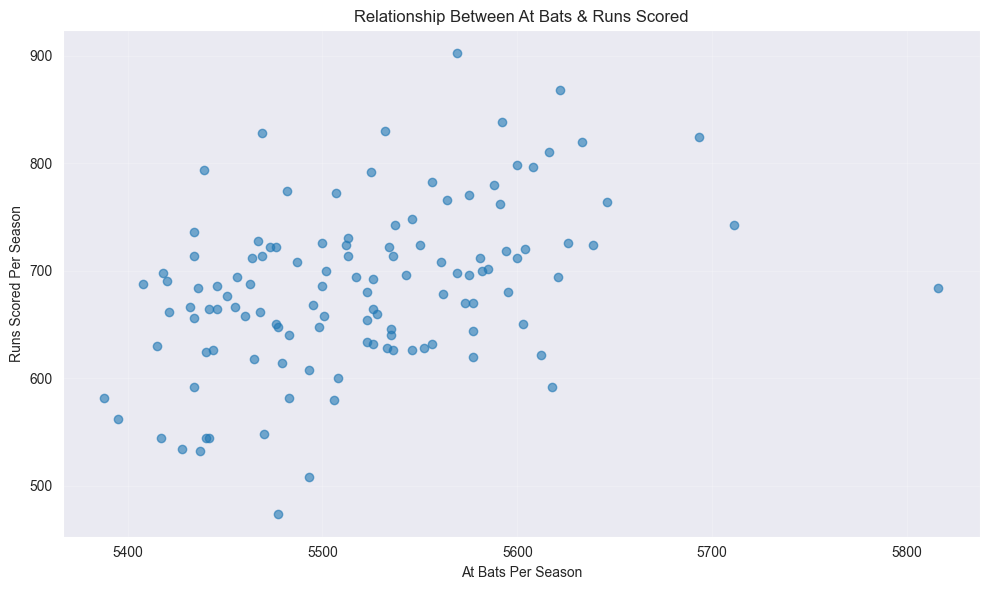

In [15]:
plt.figure(figsize= (10,6))
plt.scatter(season_stats['AtBats'], season_stats['Runs'], alpha= 0.6)
plt.xlabel('At Bats Per Season')
plt.ylabel('Runs Scored Per Season')
plt.title('Relationship Between At Bats & Runs Scored')
plt.grid(True, alpha= 0.2)
plt.tight_layout()
plt.show()

<Axes: xlabel='AtBats', ylabel='Runs'>

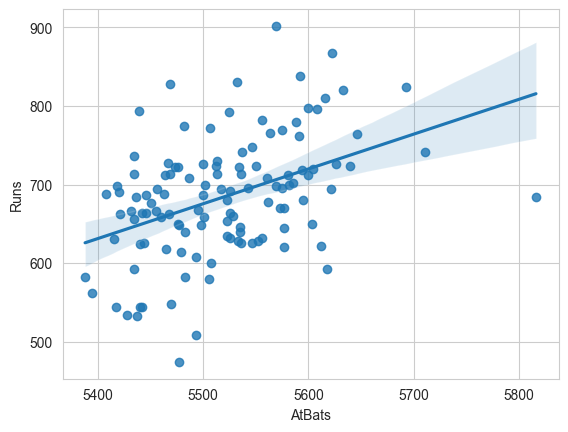

In [16]:
#with trend line
sns.set_style('whitegrid')
sns.regplot(x= 'AtBats', y= 'Runs', data= season_stats)

#### (b) Assessing relationship

If you knew a team’s at bats, would you be comfortable using a linear model to predict the number of
runs? Why or why not? Quantify the strength of the relationship with the correlation coefficient. Discuss what you find.

**2B)**
After calculating the coerrelation coefficient between the At Bats and Runs Scored, I got an output of 0.42. In order for a strong relationship to be apparent via the correlation coefficient, the outputs that are closer to 1 indicate a strong relationship and because this output is less than even half of 1, I would say that this relationship strength would be weak-to-moderate. But, if I did know the teams At Bats, I would not feel comfortable using a linear model to predict the number of runs because of the stregnth of this relationship, there would be other analysis I would want to conduct/ explore in order to feel 'comfortable'.

Correlation Coefficient: 0.423043925724762


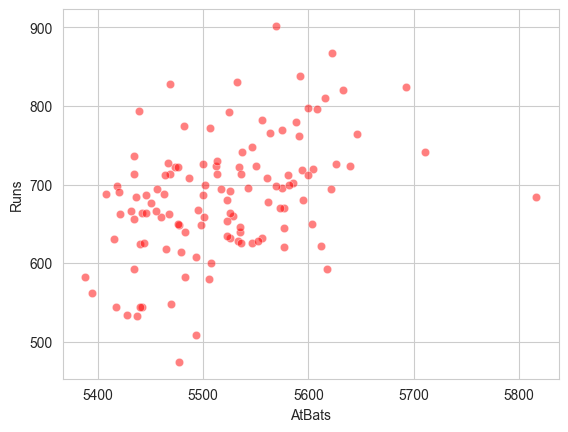

In [17]:
sns.scatterplot(data= season_stats, x= 'AtBats', y= 'Runs', color= 'Red', alpha= 0.5)
correlation_c = season_stats['AtBats'].corr(season_stats['Runs'])
print("Correlation Coefficient:", correlation_c)

#### (c) Modeling

Use the `statsmodels` package to fit a simple linear model for runs as a function of at-bats. Ensure a constant (intercept) has been added to the regression. Write down the formula for the model, filling in estimated coefficient values.

In [18]:
#using youtube video as guide : https://youtu.be/2twP7M2lfbI?si=qAZXZYUoFx0T5N6L
import statsmodels.api as sm

In [19]:
x = season_stats['AtBats'] #independent variable
y = season_stats['Runs'] #dependent

In [20]:
x_const = sm.add_constant(x)

In [21]:
model = sm.OLS(y, x_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Runs   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     25.72
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           1.48e-06
Time:                        22:12:23   Log-Likelihood:                -678.27
No. Observations:                 120   AIC:                             1361.
Df Residuals:                     118   BIC:                             1366.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1764.8376    482.943     -3.654      0.0

In [22]:
#extracting the coef values 
intercept = model.params['const']
slope = model.params['AtBats']

print(intercept)
print(slope)

-1764.8376155756832
0.44368868907437187


In [23]:
#formula 
runs = intercept + slope * season_stats['AtBats']

#### (d) Interpretation

Describe in words the interpretation of $\beta$<sub>1</sub>.

**2D)**
In this interpretation, the slope is telling us how much the number of runs is expected to change when the number of AtBats increases by 1, so because the slope = 0.4436, for every additional AtBat, a team can expect to score about 0.4436 more runs.

### Problem 3: Plotting

#### (a) Plot regression line

Make a plot of at-bats vs runs but include the fitted regression line. How well does the fitted line fit the data?

**3A)**
After making a plot of the fitted regression line, the fitted line fits the data well.

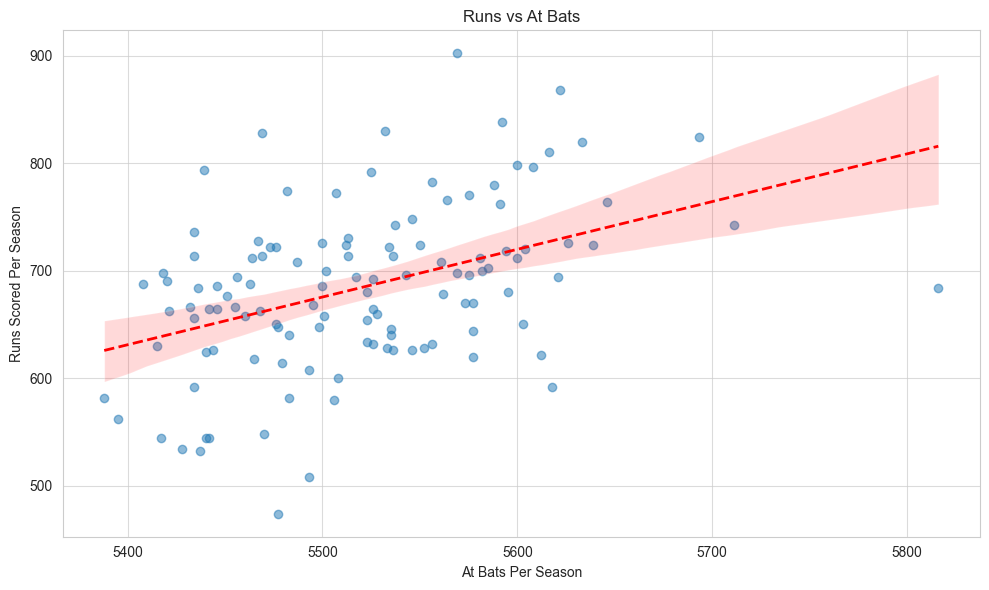

In [24]:
plt.figure(figsize= (10,6))
sns.regplot(x= 'AtBats', y='Runs', data = season_stats,
            scatter_kws= {'alpha': 0.5},
            line_kws= {'color': 'red', 'linestyle': '--', 'linewidth': 2})
plt.xlabel('At Bats Per Season')
plt.ylabel('Runs Scored Per Season')
plt.title('Runs vs At Bats')
plt.grid(True, alpha= 0.7)
plt.tight_layout()
plt.show()

#### (b) Plot residuals

Make a plot of the residuals versus at bats. Is there any apparent pattern in the residuals plot?

**3B)**
Based on this plot of residuals vs at bats, I do not see any apparent pattern, the data points are basically kind of scattered. 

In [25]:
season_stats['Residuals'] = model.resid

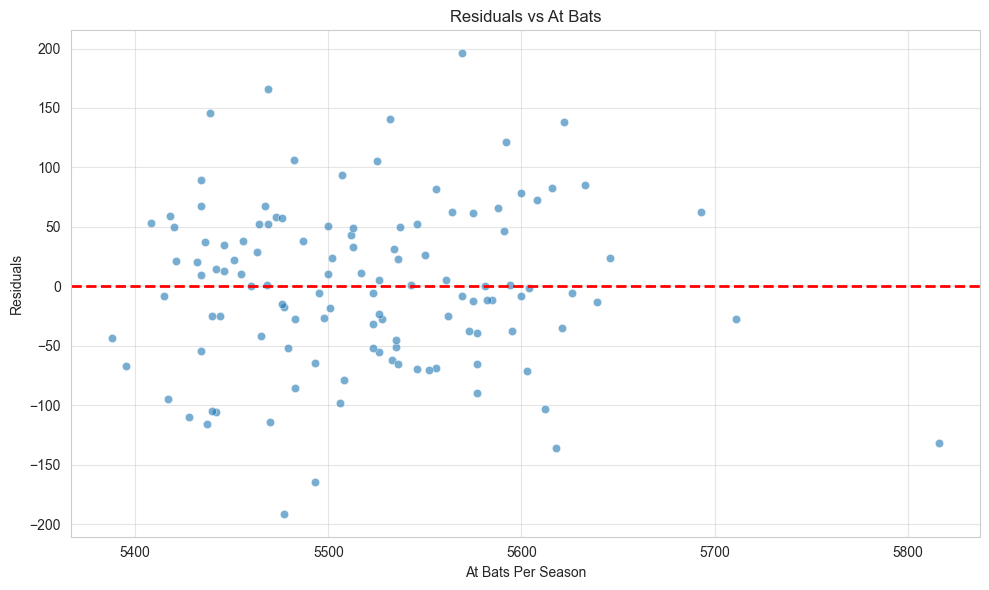

In [26]:
plt.figure(figsize= (10,6))
sns.scatterplot(data= season_stats, x='AtBats', y= 'Residuals', alpha= 0.6)
plt.axhline(0, color= 'red', linestyle= '--', linewidth= 2)
plt.xlabel('At Bats Per Season')
plt.ylabel('Residuals')
plt.title('Residuals vs At Bats')
plt.grid(True, alpha= 0.5)
plt.tight_layout()
plt.show()